# Calibration of the XY-axis in a laser scanning microscope

In this notebook, we present the procedure to calibrate the XY-axis scanner (e.g., galvanometric mirrors or piezoelectric stage) of a microscope. We used the calibration sample from Argolight. The reference patterns we used are the [3D Matrix of rings](https://argolight.com/files/Argo-SIM/Argo-SIM-v1.1_User-guide.pdf) with rings separated by 5 µm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

import brighteyes_ism.dataio.mcs as mcs
import brighteyes_ism.analysis.Tools_lib as tool
import brighteyes_ism.analysis.Graph_lib as gr

from skimage.filters import gaussian
from skimage.filters import threshold_otsu
from sklearn.cluster import KMeans

import os

## Data loading
In this case, the data are stored as an hdf5 file generated by the [BrightEyes-MCS](https://github.com/VicidominiLab/BrightEyes-MCS) software.

In [23]:
path = r'\\iitfsvge101.iit.local\mms\Data MMS server\Protocol\Calibration\Argolight_Circle_Matrix_50um\Argolight_3D_Matrix_5um-20-04-2026-12-05-35.h5'

fullpath = os.path.join(path)

with h5py.File(fullpath, 'r') as file:
    data, meta = mcs.load(fullpath)
print('Loaded data: ' + fullpath)

data = tool.CropEdge(data, npx=10, edges='lrud', order = 'rzxytc')

print(data.shape)

Loaded data: \\iitfsvge101.iit.local\mms\Data MMS server\Protocol\Calibration\Argolight_Circle_Matrix_50um\Argolight_3D_Matrix_5um-20-04-2026-12-05-35.h5
(1, 1, 881, 881, 3, 25)


To perform the acquisition, we used a 488 nm CW laser. The power is roughly 50 µW on the focal plane.
The microscope is a custom ISM setup, equipped with a 100x/1.4 oil objective lens.
The detector array size is 1.4 Airy Units.
We print the metadata, to show the acquisition parameters.

In [24]:
meta.Print()

version       0.0.1
comment       
rangex        45.0
rangey        45.0
rangez        0.0
nbin          3
dt            10.0
nx            901
ny            901
nz            1
nrep          1
calib_x       22.14784
calib_y       22.28353
calib_z       1.675


The ISM data structure is (repetition, z, y, x, time, channel). <br>
Since we are not interested in having high-resolution, we keep only the spatial dimensions (y, x).

In [25]:
data = np.sum(data, axis = (0,1,4,5))

We can crop the edges of the stack, because we are interested only in the stairway structures.

In [26]:
dset_raw = data[:,20 :]

We have a look on the image:

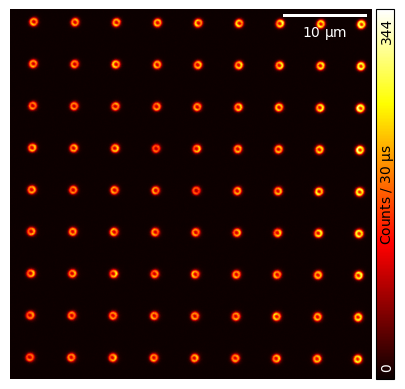

In [27]:
gr.ShowImg(dset_raw, meta.dx, meta.pxdwelltime)
plt.savefig('Argolight_Rings_XY_image.png',dpi=300)
plt.savefig('Argolight_Rings_XY_image.pdf',dpi=300)

## Pre-processing

We want to measure only the center-of-mass of each circle of the matrix.<br>
Thus, we sacrifice some resolution to denoise the dataset with a Gaussian filter.

In [7]:
dset = gaussian(dset_raw, sigma = 10)
dset /= dset.max()

We convert the image (Y, X) to a point cloud where each point contains the 2D coordinates and the corresponding intensity value.

In [8]:
point_cloud_matrix = tool.point_cloud_from_img(dset)

In [9]:
point_cloud_matrix

array([[0.00000000e+00, 0.00000000e+00, 1.19999254e-02],
       [0.00000000e+00, 1.00000000e+00, 1.18527694e-02],
       [0.00000000e+00, 2.00000000e+00, 1.17185536e-02],
       ...,
       [8.80000000e+02, 8.58000000e+02, 1.51913134e-02],
       [8.80000000e+02, 8.59000000e+02, 1.55007837e-02],
       [8.80000000e+02, 8.60000000e+02, 1.58092846e-02]],
      shape=(758541, 3))

We remove the background with the Otsu method.

In [10]:
thresh = threshold_otsu(dset)
cloud = point_cloud_matrix[ point_cloud_matrix[:, -1] > thresh ]

We look at the thresholded scatter plot.

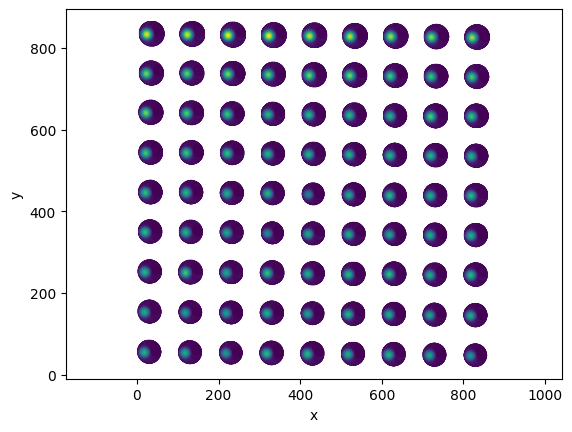

In [11]:
fig = plt.figure()
plt.scatter(cloud[:,0], cloud[:,1], c = cloud[:,2])
plt.xlabel(r'X (pixel)')
plt.ylabel(r'Y (pixel)')
plt.axis('equal')
plt.savefig('Argolight_XY_clustering.png',dpi=300)

## Data clustering

We perform K-Means clustering to identify each cloud.

In [12]:
model = KMeans(n_clusters = 81, init = "k-means++", max_iter = 300, n_init = 10, random_state = 0)
y_clusters = model.fit_predict(cloud)

cm = model.cluster_centers_
points = cm[:,0:2]

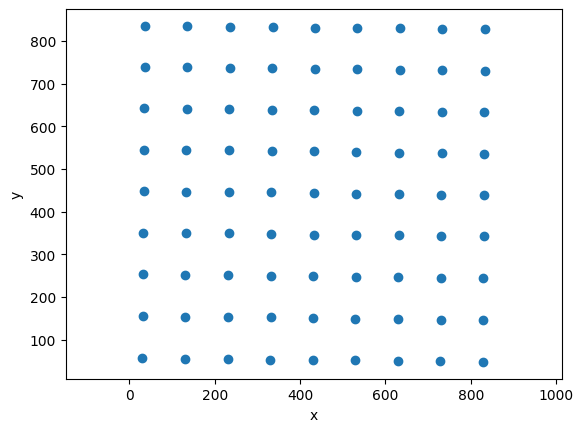

In [13]:
fig = plt.figure()
plt.scatter(cm[:,0], cm[:,1])
plt.xlabel(r'X (pixel)')
plt.ylabel(r'Y (pixel)')
plt.axis('equal')
plt.savefig('Argolight_XY_center_of_mass.png',dpi=300)

We define functions to fit this matrix of point by a 2D rectangular grid to retrieve the pitches of the grid:

In [20]:
def _wrap_residual(a, period, offset):
    return a - (offset + np.round((a - offset) / period) * period)


def _phase_offset(a, period):
    phase = 2 * np.pi * a / period
    ang = np.arctan2(np.mean(np.sin(phase)), np.mean(np.cos(phase)))
    return (ang % (2 * np.pi)) * period / (2 * np.pi)


def _pairwise_distances(points):
    diff = points[:, None, :] - points[None, :, :]
    D = np.sqrt(np.sum(diff**2, axis=2))
    np.fill_diagonal(D, np.inf)
    return D


def _estimate_theta_from_knn(points, k=6):
    """
    Estimate grid orientation from the angles of the k nearest neighbors.
    For a rectangular grid the orientation is periodic every 90 degrees.
    """
    pts = np.asarray(points, float)
    D = _pairwise_distances(pts)
    idx = np.argsort(D, axis=1)[:, :k]

    vecs = pts[idx] - pts[:, None, :]
    ang = np.arctan2(vecs[..., 1].ravel(), vecs[..., 0].ravel())

    z = np.exp(1j * 4 * ang)
    theta0 = 0.25 * np.angle(np.mean(z))
    return theta0


def _best_period_1d(a, p_center, rel_span=0.4, n_grid=81):
    """
    Best period for one coordinate axis by 1D grid search.
    """
    p_min = max(1e-12, p_center * (1 - rel_span))
    p_max = max(p_min * 1.001, p_center * (1 + rel_span))

    best = None
    for p in np.linspace(p_min, p_max, n_grid):
        off = _phase_offset(a, p)
        r = _wrap_residual(a, p, off)
        score = np.mean(r**2)
        if best is None or score < best["score"]:
            best = {"period": p, "offset": off, "score": score}
    return best


def fit_unordered_rotated_rect_grid(points, n_rows=None, n_cols=None, plot=True, ax=None):
    """
    Fit a rotated rectangular grid to an unordered set of points (N, 2).

    Parameters
    ----------
    points : array, shape (N, 2)
        Unordered point coordinates.
    n_rows, n_cols : int or None
        Expected grid dimensions. If omitted and N is a perfect square,
        uses sqrt(N) x sqrt(N) only for initialization.
    plot : bool
        If True, show raw points and fitted rectangular lattice.
    ax : matplotlib axis or None
        Optional axis.

    Returns
    -------
    result : dict
        pitch_x, pitch_y, theta_rad, theta_deg, origin, row_indices,
        col_indices, fitted_points, fitted_grid, rmse, ...
    """
    pts = np.asarray(points, dtype=float)
    if pts.ndim != 2 or pts.shape[1] != 2:
        raise ValueError("points must have shape (N, 2)")

    N = len(pts)

    if n_rows is None and n_cols is None:
        n = int(round(np.sqrt(N)))
        if n * n == N:
            n_rows = n
            n_cols = n
        else:
            raise ValueError("Provide n_rows and n_cols when N is not a perfect square")
    elif n_rows is None:
        if N % n_cols != 0:
            raise ValueError("N is not divisible by n_cols")
        n_rows = N // n_cols
    elif n_cols is None:
        if N % n_rows != 0:
            raise ValueError("N is not divisible by n_rows")
        n_cols = N // n_rows

    # Rough nearest-neighbor scale, mostly for reference
    D = _pairwise_distances(pts)
    nn = D.min(axis=1)
    pitch0 = np.median(nn)

    # Initial angle estimate
    theta0 = _estimate_theta_from_knn(pts, k=min(6, N - 1))

    # Initial pitch_x / pitch_y from projected extents
    c0, s0 = np.cos(theta0), np.sin(theta0)
    u0_est = c0 * pts[:, 0] + s0 * pts[:, 1]
    v0_est = -s0 * pts[:, 0] + c0 * pts[:, 1]

    span_u = np.percentile(u0_est, 99) - np.percentile(u0_est, 1)
    span_v = np.percentile(v0_est, 99) - np.percentile(v0_est, 1)

    pitch_x0 = span_u / max(n_cols - 1, 1)
    pitch_y0 = span_v / max(n_rows - 1, 1)

    if not np.isfinite(pitch_x0) or pitch_x0 <= 0:
        pitch_x0 = pitch0
    if not np.isfinite(pitch_y0) or pitch_y0 <= 0:
        pitch_y0 = pitch0

    def evaluate_theta(theta, px_center, py_center, rel_span_x, rel_span_y,
                       n_px=61, n_py=61):
        c, s = np.cos(theta), np.sin(theta)
        u = c * pts[:, 0] + s * pts[:, 1]
        v = -s * pts[:, 0] + c * pts[:, 1]

        bx = _best_period_1d(u, px_center, rel_span=rel_span_x, n_grid=n_px)
        by = _best_period_1d(v, py_center, rel_span=rel_span_y, n_grid=n_py)

        return {
            "score": bx["score"] + by["score"],
            "theta": theta,
            "pitch_x": bx["period"],
            "pitch_y": by["period"],
            "u_off": bx["offset"],
            "v_off": by["offset"],
            "u": u,
            "v": v,
        }

    # Coarse search on theta, optimize pitch_x and pitch_y independently
    best = None
    for theta in np.linspace(theta0 - np.deg2rad(20), theta0 + np.deg2rad(20), 121):
        cur = evaluate_theta(theta, pitch_x0, pitch_y0, rel_span_x=0.5, rel_span_y=0.5,
                             n_px=61, n_py=61)
        if best is None or cur["score"] < best["score"]:
            best = cur

    # Two refinements
    for theta_span_deg, relx, rely, ntheta, npx, npy in [
        (3.0, 0.15, 0.15, 121, 61, 61),
        (0.6, 0.04, 0.04, 121, 61, 61),
    ]:
        new_best = best
        for theta in np.linspace(best["theta"] - np.deg2rad(theta_span_deg),
                                 best["theta"] + np.deg2rad(theta_span_deg), ntheta):
            cur = evaluate_theta(theta, best["pitch_x"], best["pitch_y"],
                                 rel_span_x=relx, rel_span_y=rely,
                                 n_px=npx, n_py=npy)
            if cur["score"] < new_best["score"]:
                new_best = cur
        best = new_best

    theta = best["theta"]
    pitch_x = best["pitch_x"]
    pitch_y = best["pitch_y"]
    u_off = best["u_off"]
    v_off = best["v_off"]

    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s],
                  [s,  c]])

    u = c * pts[:, 0] + s * pts[:, 1]
    v = -s * pts[:, 0] + c * pts[:, 1]

    # Integer lattice indices
    col_idx = np.round((u - u_off) / pitch_x).astype(int)
    row_idx = np.round((v - v_off) / pitch_y).astype(int)

    col_min = col_idx.min()
    row_min = row_idx.min()

    col_idx = col_idx - col_min
    row_idx = row_idx - row_min

    n_cols_fit = col_idx.max() + 1
    n_rows_fit = row_idx.max() + 1

    # Origin in grid frame and in XY frame
    origin_uv = np.array([
        u_off + col_min * pitch_x,
        v_off + row_min * pitch_y
    ])
    origin_xy = origin_uv @ R.T

    # Fitted point corresponding to each raw point
    grid_uv = np.column_stack([col_idx * pitch_x, row_idx * pitch_y])
    fitted_pts = origin_xy + grid_uv @ R.T

    residual = pts - fitted_pts
    rmse = np.sqrt(np.mean(np.sum(residual**2, axis=1)))

    # Full fitted grid
    cc, rr = np.meshgrid(np.arange(n_cols_fit), np.arange(n_rows_fit))
    full_uv = np.stack([cc * pitch_x, rr * pitch_y], axis=-1)
    fitted_grid = origin_xy + full_uv @ R.T

    result = {
        "pitch0": pitch0,
        "pitch_x0": pitch_x0,
        "pitch_y0": pitch_y0,
        "pitch_x": pitch_x,
        "pitch_y": pitch_y,
        "theta_rad": theta,
        "theta_deg": np.degrees(theta),
        "origin": origin_xy,
        "row_indices": row_idx,
        "col_indices": col_idx,
        "indices": np.column_stack([row_idx, col_idx]),
        "fitted_points": fitted_pts,
        "fitted_grid": fitted_grid,
        "rmse": rmse,
        "n_rows_fit": n_rows_fit,
        "n_cols_fit": n_cols_fit,
    }

    if plot:
        if ax is None:
            fig, ax = plt.subplots(figsize=(7, 7))

        ax.scatter(pts[:, 0], pts[:, 1], s=35, label="raw points")
        # ax.scatter(fitted_pts[:, 0], fitted_pts[:, 1], marker="x", s=55, label="fitted points")

        for p_raw, p_fit in zip(pts, fitted_pts):
            ax.plot([p_raw[0], p_fit[0]], [p_raw[1], p_fit[1]], alpha=0.35, linewidth=0.8)

        for r in range(fitted_grid.shape[0]):
            ax.plot(fitted_grid[r, :, 0], fitted_grid[r, :, 1], alpha=0.8,color = 'red')
        for cidx in range(fitted_grid.shape[1]):
            ax.plot(fitted_grid[:, cidx, 0], fitted_grid[:, cidx, 1], alpha=0.8,color = 'red')

        ax.set_aspect("equal")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(
            f"Rectangular grid fit\n"
            f"pitch_x = {pitch_x:.4f}, pitch_y = {pitch_y:.4f}, "
            f"angle = {np.degrees(theta):.3f} deg, RMSE = {rmse:.4f}"
        )
        # ax.grid(True)
        ax.legend()
        plt.savefig('Argolight_XY_Fit_Grid.png',dpi=300)
        plt.savefig('Argolight_XY_Fit_Grid.pdf',dpi=300)
    return result

initial NN pitch : 96.87061331253324
initial pitch_x0 : 99.81663758204306
initial pitch_y0 : 97.71012391170834
fitted pitch_x   : 99.68354873193367
fitted pitch_y   : 97.35120205653932
angle (deg)      : -0.5038778192170571
RMSE             : 1.156378649244132
grid size found  : 9 x 9


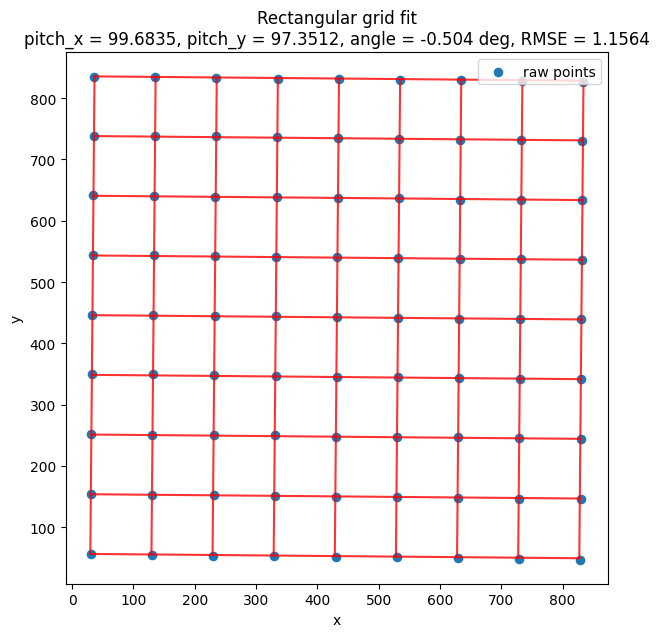

In [21]:
result = fit_unordered_rotated_rect_grid(points, n_rows=9, n_cols=9, plot=True)

print("initial NN pitch :", result["pitch0"])
print("initial pitch_x0 :", result["pitch_x0"])
print("initial pitch_y0 :", result["pitch_y0"])
print("fitted pitch_x   :", result["pitch_x"])
print("fitted pitch_y   :", result["pitch_y"])
print("angle (deg)      :", result["theta_deg"])
print("RMSE             :", result["rmse"])
print("grid size found  :", result["n_rows_fit"], "x", result["n_cols_fit"])

We convert the pixels into Volts.

In [16]:
V_pitch_x = result["pitch_x"] * meta.dx / meta.calib_x 
V_pitch_y = result["pitch_y"] * meta.dx / meta.calib_x 

The pitch corresponds to 5 µm on the calibrated sample.

In [17]:
pitch_real = 5 # in µm
calib_x = pitch_real / V_pitch_x # in µm per V
calib_y = pitch_real / V_pitch_y # in µm per V

print(f'Calibration Factor X axis: {calib_x} µm/V')
print(f'Calibration Factor Y axis: {calib_y} µm/V')


Calibration Factor X axis: 22.242836449108232 µm/V
Calibration Factor Y axis: 22.775731827362403 µm/V
